In [ ]:
# MODEL TRAINING BEFORE TUNING
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix # for model evaluation
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('0.4_scaled_data.csv')

X = df.drop(columns=['Burnout_Risk'])
y = df['Burnout_Risk']

# 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize & Train RandomForest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Save the trained model
model_filename = 'before_tuning.pkl'
joblib.dump(rf_model, model_filename)

# also save the test sets so they can be loaded by the evaluation script
joblib.dump(X_test, 'X_test.pkl')
joblib.dump(y_test, 'y_test.pkl')

# Generate Evaluation (F1 and Confusion Matrix)
y_pred = rf_model.predict(X_test)

# Assuming multi-class or binary, using weighted to be safe
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix (Before Tuning)\nF1 Score: {f1:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()

# Save the plot
plot_filename = 'confusion_matrix_before_tuning.png'
plt.savefig(plot_filename, dpi=300)
plt.close()

print(f"[{model_filename}] Model saved successfully.")
print(f"[{plot_filename}] Plot saved successfully.")
print(f"F1 Score: {f1:.4f}")

[before_tuning.pkl] Model saved successfully.
[confusion_matrix_before_tuning.png] Plot saved successfully.
F1 Score: 0.7947


TUNING. WAIT
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
F1-Score (After Tuning): 0.7981

 saved in 'after_tuning.pkl'
saved in 'after_tuning_evaluation.png'


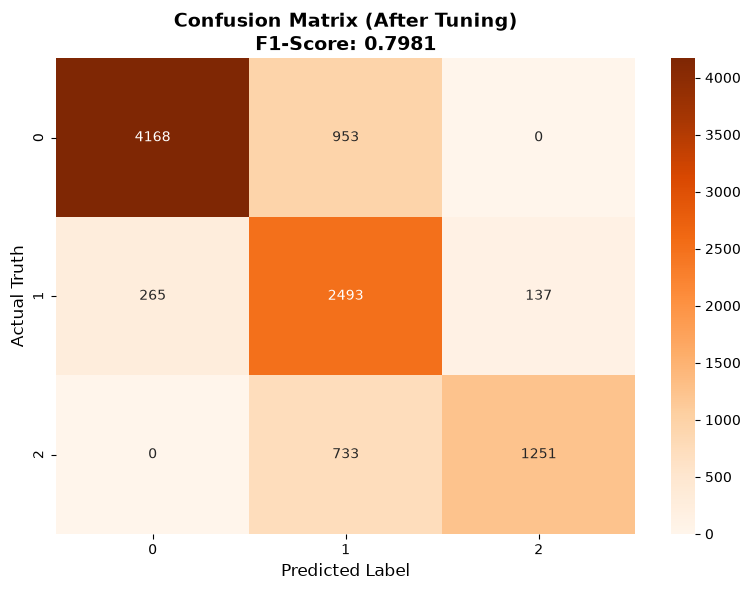

In [ ]:
# Hyperparameter Tuning
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

df = pd.read_csv('0.4_scaled_data.csv')
target_col = 'Burnout_Risk'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("TUNING. WAIT")

# RandomizedSearchCV
rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=20,         
    cv=3,               
    scoring='f1_weighted', 
    n_jobs=-1,         
    random_state=42,
    verbose=2
)
# START TUNING
random_search.fit(X_train, y_train)

# Find the best one
best_model = random_search.best_estimator_
print(f"\nBest: {random_search.best_params_}")

# Evaluate the model in the test data set
y_pred = best_model.predict(X_test)
f1_after = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (After Tuning): {f1_after:.4f}")

# NewConfusion Matrix (After tuning)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)

plt.title(f'Confusion Matrix (After Tuning)\nF1-Score: {f1_after:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Truth', fontsize=12)
plt.tight_layout()

# New file 
plt.savefig('after_tuning_evaluation.png', dpi=300)
joblib.dump(best_model, 'after_tuning.pkl')
print("\n saved in 'after_tuning.pkl'")
print("saved in 'after_tuning_evaluation.png'") 